# Trenberth Full Diagram — Candidate B: Per-Block Gradient Clipping

Same 20-parameter, 6-flux calibration as `trenberth_full.ipynb`. The one change: `grad_clip`
now clips the SW/albedo block (params 1-15) and the LW-transmissivity+emissivity block (params
16-20) **independently**, instead of one shared global-L2-norm budget across all 20 parameters.

**Why:** diagnostics added to `calibrate!` (see `history[:grad_norm]`/`history[:clipped]`)
showed `grad_clip=5.0` was saturating on **100% of batches** in the production run — meaning
it wasn't an occasional safety clamp, it was a *permanent* renormalization of the whole
gradient vector every step. The LW-transmissivity block's raw gradients (`fl`≈600,
`tau0_equator`≈400) structurally dominate that shared budget over the SW block's, every batch,
regardless of whether the SW block has already converged. Per-block clipping lets each block
occupy its own clip budget so the SW block isn't perpetually dragged along by the LW block's
push (or vice versa) — without a hard freeze, which was already tried and made things worse
(see `project_trenberth_lw_transmissivity_gradscale_fix` memory, "fl-frozen result: REFUTED").

**Expected runtime:** ~8–12 hours at T31 for the full run. Run the quick test (Section 4) first.

## 1. Setup

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using SpeedyCalibration
using Optimisers
using CairoMakie
using GeoMakie
using Dates
using Printf

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`
[ Info: Precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]
┌ Warning: Module GPUArrays with build ID fafbfcfd-cbcf-b0af-d415-307bdc528ba8 is missing from the cache.
│ This may mean GPUArrays [0c68f7d7-f131-5f86-a1c3-88cf8149b2d7] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2018
┌ Error: Error during loading of extension ComponentArraysGPUArraysExt of ComponentArrays, use `Base.retry_load_extensions()` to retry.
│   exception =
│    1-element ExceptionStack:
│    Declaring __precompile__(false) is not allowed in files that are being precompiled.
│    Stacktrace:
│      [1] _require(pkg::Base.PkgId, env::Nothing)
│        @ Base ./loading.jl:2069
│      [2] __require_prelocked(uuidkey::Base.PkgId, env::Nothing)
│        @ Base ./loading.jl:1882
│      [3] #invoke_in_world#3
│        @ ./essentials.jl:926 [inlined]
│      [4] invoke_in_world
│

## 2. Define Trainable Parameters (identical to `trenberth_full.ipynb`, plus the block split)

In [3]:
param_specs = [
    # ── SW cloud reflection ───────────────────────────────────────────────────
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:stratocumulus_cover_max,
        [:shortwave_radiation, :clouds, :stratocumulus_cover_max];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:stratocumulus_albedo,
        [:shortwave_radiation, :clouds, :stratocumulus_albedo];
        bounds=(0.10f0, 0.90f0), initial=0.50f0),
    ParamSpec(:precipitation_weight,
        [:shortwave_radiation, :clouds, :precipitation_weight];
        bounds=(0.0f0, 0.8f0), initial=0.20f0),

    # ── SW atmospheric absorption ─────────────────────────────────────────────
    ParamSpec(:absorptivity_water_vapor,
        [:shortwave_radiation, :transmissivity, :absorptivity_water_vapor];
        bounds=(60f0, 140f0), initial=75f0, grad_scale=0.01f0),
    ParamSpec(:absorptivity_dry_air,
        [:shortwave_radiation, :transmissivity, :absorptivity_dry_air];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),
    ParamSpec(:absorptivity_aerosol,
        [:shortwave_radiation, :transmissivity, :absorptivity_aerosol];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),
    ParamSpec(:ozone_absorption,
        [:shortwave_radiation, :radiative_transfer, :ozone_absorption];
        bounds=(0.002f0, 0.020f0), initial=0.01f0),

    # ── Surface albedo ────────────────────────────────────────────────────────
    ParamSpec(:albedo_land,
        [:albedo, :land, :albedo_land];
        bounds=(0.10f0, 0.70f0), initial=0.40f0),
    ParamSpec(:albedo_high_vegetation,
        [:albedo, :land, :albedo_high_vegetation];
        bounds=(0.04f0, 0.26f0), initial=0.15f0),
    ParamSpec(:albedo_low_vegetation,
        [:albedo, :land, :albedo_low_vegetation];
        bounds=(0.05f0, 0.35f0), initial=0.20f0),
    ParamSpec(:albedo_snow,
        [:albedo, :land, :albedo_snow];
        bounds=(0.15f0, 0.75f0), initial=0.40f0),
    ParamSpec(:snow_depth_scale,
        [:albedo, :land, :snow_depth_scale];
        bounds=(0.005f0, 0.20f0), initial=0.05f0),
    ParamSpec(:albedo_ocean,
        [:albedo, :ocean, :albedo_ocean];
        bounds=(0.02f0, 0.10f0), initial=0.06f0),
    ParamSpec(:albedo_ice,
        [:albedo, :ocean, :albedo_ice];
        bounds=(0.30f0, 0.90f0), initial=0.60f0),

    # ── Longwave transmissivity (Frierson scheme) ─────────────────────────────
    ParamSpec(:tau0_equator,
        [:longwave_radiation, :transmissivity, :τ₀_equator];
        bounds=(2f0, 12f0), initial=6f0, grad_scale=0.04f0),
    ParamSpec(:tau0_pole,
        [:longwave_radiation, :transmissivity, :τ₀_pole];
        bounds=(0.3f0, 4f0), initial=1.5f0, grad_scale=0.25f0),
    ParamSpec(:fl,
        [:longwave_radiation, :transmissivity, :fₗ];
        bounds=(0.0f0, 0.5f0), initial=0.1f0, grad_scale=0.025f0),

    # ── Longwave emissivity ───────────────────────────────────────────────────
    ParamSpec(:emissivity_ocean,
        [:longwave_radiation, :radiative_transfer, :emissivity_ocean];
        bounds=(0.80f0, 1.00f0), initial=0.98f0, grad_scale=0.2f0),
    ParamSpec(:emissivity_land,
        [:longwave_radiation, :radiative_transfer, :emissivity_land];
        bounds=(0.80f0, 1.00f0), initial=0.98f0, grad_scale=0.5f0),

    # infiltration_fraction, ocean_moisture, snow_melting_threshold intentionally
    # excluded -- bit-exact-zero AD gradient under this training method (see
    # project_trenberth_lw_transmissivity_gradscale_fix memory).
]

# Indices 1:15 = SW/albedo block, 16:20 = LW-transmissivity+emissivity block --
# this split matches the ablation staging that isolated the LW block as the
# source of the shared-grad_clip-budget dominance (see param_specs comments in
# trenberth_full.ipynb and project_trenberth_lw_transmissivity_gradscale_fix).
sw_block_idx = collect(1:15)
lw_block_idx = collect(16:20)

println("$(length(param_specs)) trainable parameters defined ($(length(sw_block_idx)) SW/albedo, $(length(lw_block_idx)) LW).")

20 trainable parameters defined (15 SW/albedo, 5 LW).


## 3. Configure the Loss Function (unchanged — relative-error weighting, no hinge)

In [4]:
# Same objective relative-error weighting as the production trenberth_full.ipynb
# (weight_k = (osr_target/target_k)^2), unchanged -- this experiment only changes
# HOW gradients get clipped, not the loss itself.
loss_config = LossConfig(
    [:osr, :sru, :srd, :olr, :lrd, :lru];
    targets = Dict(:osr => 101.9f0, :sru =>  23.0f0, :srd => 168.0f0,
                   :olr => 235.0f0, :lrd => 333.0f0, :lru => 398.0f0),
    weights = Dict(:osr => 1.00000f0, :sru => 19.62875f0, :srd => 0.36790f0,
                   :olr => 0.18802f0, :lrd => 0.09364f0,  :lru => 0.06555f0),
)

println("Loss configuration: $(length(loss_config.flux_keys))-flux MSE (relative-error weighting, no hinge)")
println()
@printf("  %-6s  %8s  %10s\n", "flux", "target", "weight")
println("  " * "-" ^ 28)
for k in loss_config.flux_keys
    @printf("  %-6s  %6.1f W/m²  %10.5f\n",
            k, loss_config.targets[k], loss_config.weights[k])
end

Loss configuration: 6-flux MSE (relative-error weighting, no hinge)

  flux      target      weight
  ----------------------------
  osr      101.9 W/m²     1.00000
  sru       23.0 W/m²    19.62875
  srd      168.0 W/m²     0.36790
  olr      235.0 W/m²     0.18802
  lrd      333.0 W/m²     0.09364
  lru      398.0 W/m²     0.06555


## 4. Quick Test

Verifies the per-block clip path (`config.clip_groups`) runs cleanly before the full run.

In [5]:
result_test = calibrate!(
    param_specs,
    Optimisers.Adam(5f-3),
    loss_config,
    quick_test_config(; clip_groups=[sw_block_idx, lw_block_idx]),
)

println("Quick test complete: ", result_test.conv_info.stop_reason)
println("\ngrad_norm (global, for reference) per batch: ", result_test.history[:grad_norm])
println("clipped per batch: ", result_test.history[:clipped])

[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. precipitation_weight             = 0.2000  [0.000, 0.800]  raw₀=-1.099
   5. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   6. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   7. absorptivity_aerosol             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   8. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   9. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
  10. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
  11. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  12. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  13. snow_depth_scale                 

┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123


Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 0.0 s.
Starting training...
----------------------------------------------------------------------
Batch 1: all gradient samples invalid, stopping.

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.6000
  stratocumulus_cover_max          0.6000 → 0.6000
  stratocumulus_albedo             0.5000 → 0.5000
  precipitation_weight             0.2000 → 0.2000
  absorptivity_water_vapor         75.0000 → 75.0000
  absorptivity_dry_air             0.0314 → 0.0314
  absorptivity_aerosol             0.0314 → 0.0314
  ozone_absorption                 0.0100 → 0.0100
  albedo_land                      0.4000 → 0.4000
  albedo_high_vegetation           0.1500 → 0.1500
  albedo_low_vegetation            0.2000 → 0.2000
  albedo_snow                      0.4000 → 0.4000
  snow_depth_scale                 0.0500 → 0.0500
  albedo_ocean                     0.0600 → 0.0600
  albedo_ice                      

---

## 5. Full Training Run

**⏱ Expected runtime: ~8–12 hours at T31.**

Identical `TrainingConfig` to `trenberth_full.ipynb` except `clip_groups=[sw_block_idx, lw_block_idx]`.

In [6]:
save_path = joinpath(@__DIR__, "output", "trenberth_perblock_clip_result.jld2")
if isfile(save_path)
    result = load_result(save_path)
    println("Loaded existing result from: $save_path")
    println("  best_batch: ", result.conv_info.best_batch,
            "  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=2),
            "  stop_reason: ", result.conv_info.stop_reason)
else
    result = calibrate!(
        param_specs,
        Optimisers.Adam(5f-3),
        loss_config,
        TrainingConfig(
            spinup_days       = 180,
            batch_days        = 2.0,
            samples_per_batch = 10,
            max_batches       = 400,
            loss_threshold    = 1f-6,
            enable_lr_decay   = false,
            trunc             = 31,
            nlayers           = 8,
            daily_cycle       = true,
            clip_groups       = [sw_block_idx, lw_block_idx],
        ),
    )
    mkpath(dirname(save_path))
    save_result(result, save_path)
    println("Result saved to: $save_path")
end

SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. precipitation_weight             = 0.2000  [0.000, 0.800]  raw₀=-1.099
   5. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   6. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   7. absorptivity_aerosol             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   8. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   9. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
  10. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
  11. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  12. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  13. snow_depth_scale                 

   0%  ETA: 4:10:31 (2000-09-17, 571.97 years/day, 106 m/s, [ -87,   28] ˚C)

Spinup complete in 77.7 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 230.1 s.
Starting training...
----------------------------------------------------------------------


   0%  ETA: 17:03:52 (2000-09-18, 139.94 years/day, 103 m/s, [ -87,   27] ˚C)

Batch   1 | LR 5.0e-03 | osr= 85.5 sru= 23.8 srd=203.7 olr=248.8 lrd=330.6 lru=397.6 | L̄   785.22 | Δp 0.0e+00 | ‖g‖  1058.8→5.0*


...

Batch 350 | LR 5.0e-03 | osr=101.9 sru= 22.3 srd=168.3 olr=239.5 lrd=360.6 lru=398.2 | L̄    88.47 | Δp 1.3e-03 | ‖g‖    34.7→5.0*


   2%  ETA: 15:26:11 (2002-08-27, 151.69 years/day, 104 m/s, [-110,   37] ˚C)

Batch 355 | LR 5.0e-03 | osr=101.0 sru= 22.4 srd=169.2 olr=239.5 lrd=361.3 lru=398.3 | L̄    87.25 | Δp 1.4e-03 | ‖g‖    28.9→5.0*


   2%  ETA: 15:25:16 (2002-09-02, 151.81 years/day,  93 m/s, [-107,   38] ˚C)

EARLY STOP: no improvement for 30 batches (best batch 328, best smoothed_loss 86.4912)

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.8276
  stratocumulus_cover_max          0.6000 → 0.8294
  stratocumulus_albedo             0.5000 → 0.7637
  precipitation_weight             0.2000 → 0.5540
  absorptivity_water_vapor         75.0000 → 66.1220
  absorptivity_dry_air             0.0314 → 0.0140
  absorptivity_aerosol             0.0314 → 0.0171
  ozone_absorption                 0.0100 → 0.0044
  albedo_land                      0.4000 → 0.2175
  albedo_high_vegetation           0.1500 → 0.1078
  albedo_low_vegetation            0.2000 → 0.1376
  albedo_snow                      0.4000 → 0.6367
  snow_depth_scale                 0.0500 → 0.0190
  albedo_ocean                     0.0600 → 0.0941
  albedo_ice                       0.6000 → 0.8546
  tau0_equator                     6.0000 → 7.9156
  tau0_pole                        1.5000 → 0.9168
  fl                      

## 6. Inspect Results

In [7]:
println(result)
println()
println("Convergence info:")
println("  stop_reason:        ", result.conv_info.stop_reason)
println("  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=2))
println("  total_batches:      ", result.conv_info.total_batches)
@printf("  total_time:         %.1f hours\n", result.conv_info.total_time / 3600)

TrainingResult(358 batches, stop=no improvement for 30 batches, best_loss=86.4912)

Convergence info:
  stop_reason:        no improvement for 30 batches
  best_smoothed_loss: 86.49
  total_batches:      358
  total_time:         0.4 hours


In [8]:
@printf("\n%-28s  %10s  %10s  %10s\n", "parameter", "initial", "trained", "change")
println("-" ^ 65)
for spec in result.param_specs
    init    = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = result.final_params[spec.name]
    @printf("%-28s  %10.4g  %10.4g  %+10.4g\n",
            spec.name, init, trained, trained - init)
end


parameter                        initial     trained      change
-----------------------------------------------------------------
cloud_albedo                         0.6      0.8276     +0.2276
stratocumulus_cover_max              0.6      0.8294     +0.2294
stratocumulus_albedo                 0.5      0.7637     +0.2637
precipitation_weight                 0.2       0.554      +0.354
absorptivity_water_vapor              75       66.12      -8.878
absorptivity_dry_air             0.03135     0.01401    -0.01734
absorptivity_aerosol             0.03135     0.01708    -0.01427
ozone_absorption                    0.01    0.004408   -0.005592
albedo_land                          0.4      0.2175     -0.1825
albedo_high_vegetation              0.15      0.1078    -0.04219
albedo_low_vegetation                0.2      0.1376    -0.06245
albedo_snow                          0.4      0.6367     +0.2367
snow_depth_scale                    0.05     0.01902    -0.03098
albedo_ocean           

In [9]:
@printf("\n%-6s  %8s  %8s  %8s\n", "flux", "target", "trained", "bias")
println("-" ^ 38)
for k in result.loss_config.flux_keys
    tgt  = result.loss_config.targets[k]
    val  = result.history[k][end]
    @printf("%-6s  %8.2f  %8.2f  %+8.2f\n", k, tgt, val, val - tgt)
end


flux      target   trained      bias
--------------------------------------
osr       101.90    100.36     -1.54
sru        23.00     22.27     -0.73
srd       168.00    169.10     +1.10
olr       235.00    239.47     +4.47
lrd       333.00    361.94    +28.94
lru       398.00    398.36     +0.36


## 7. Plot Training History

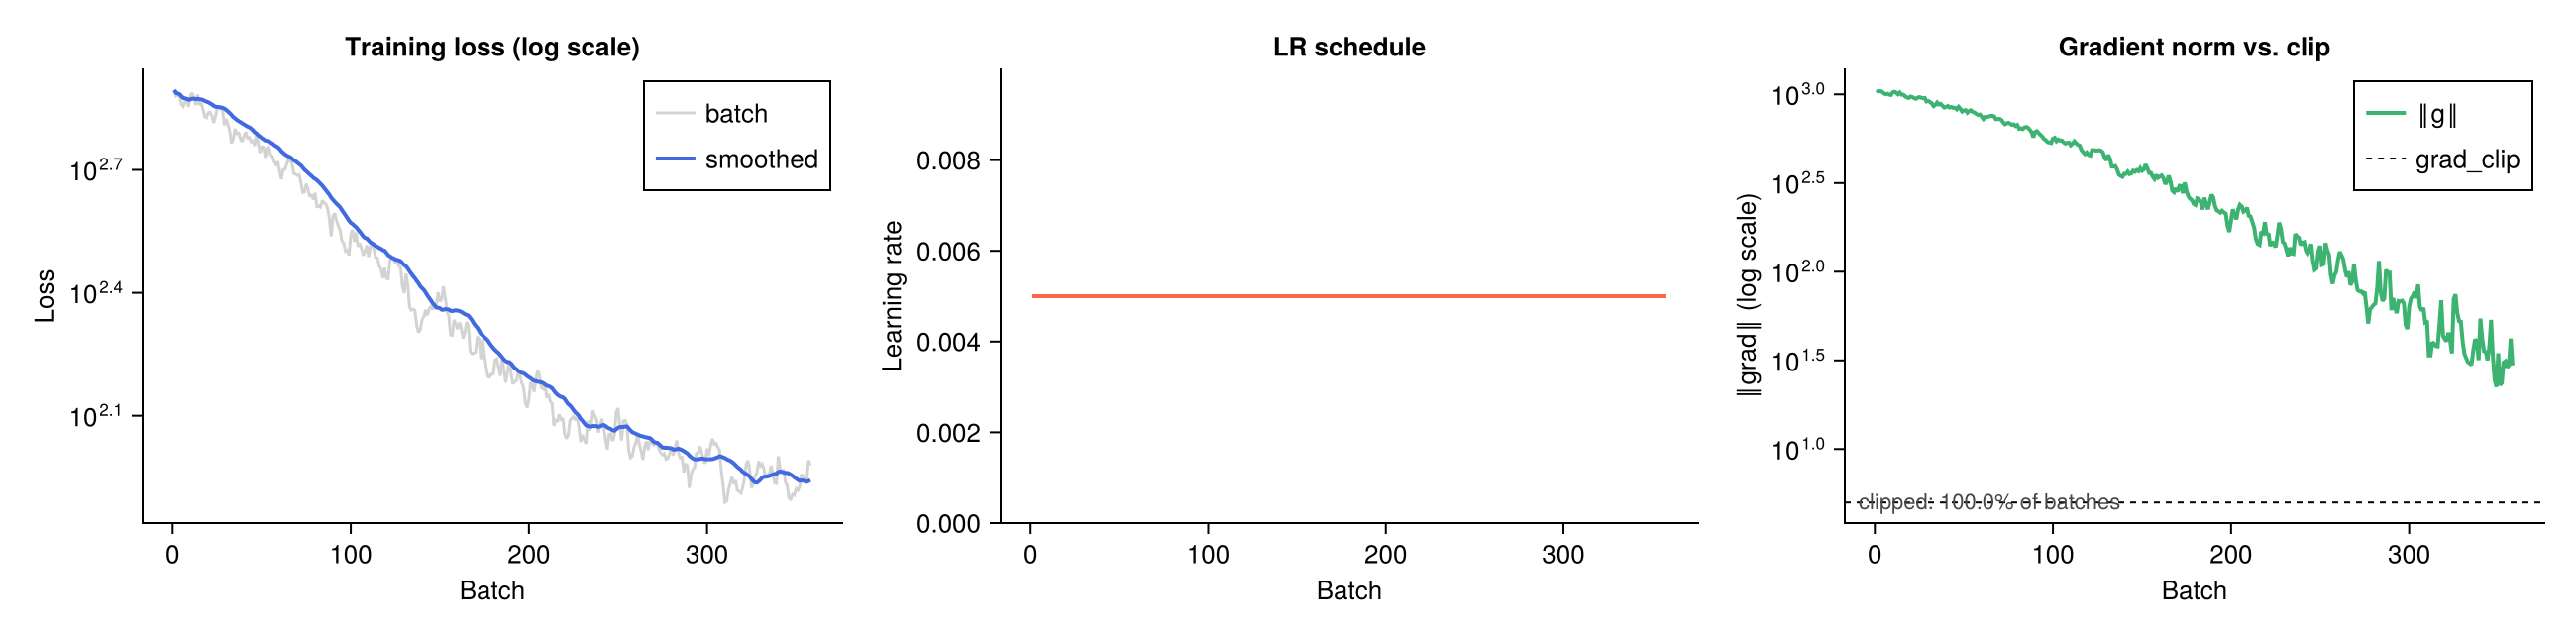

In [10]:
figs = plot_training(result; save_dir=joinpath(@__DIR__, "output", "trenberth_perblock_clip"))
figs.fig_loss

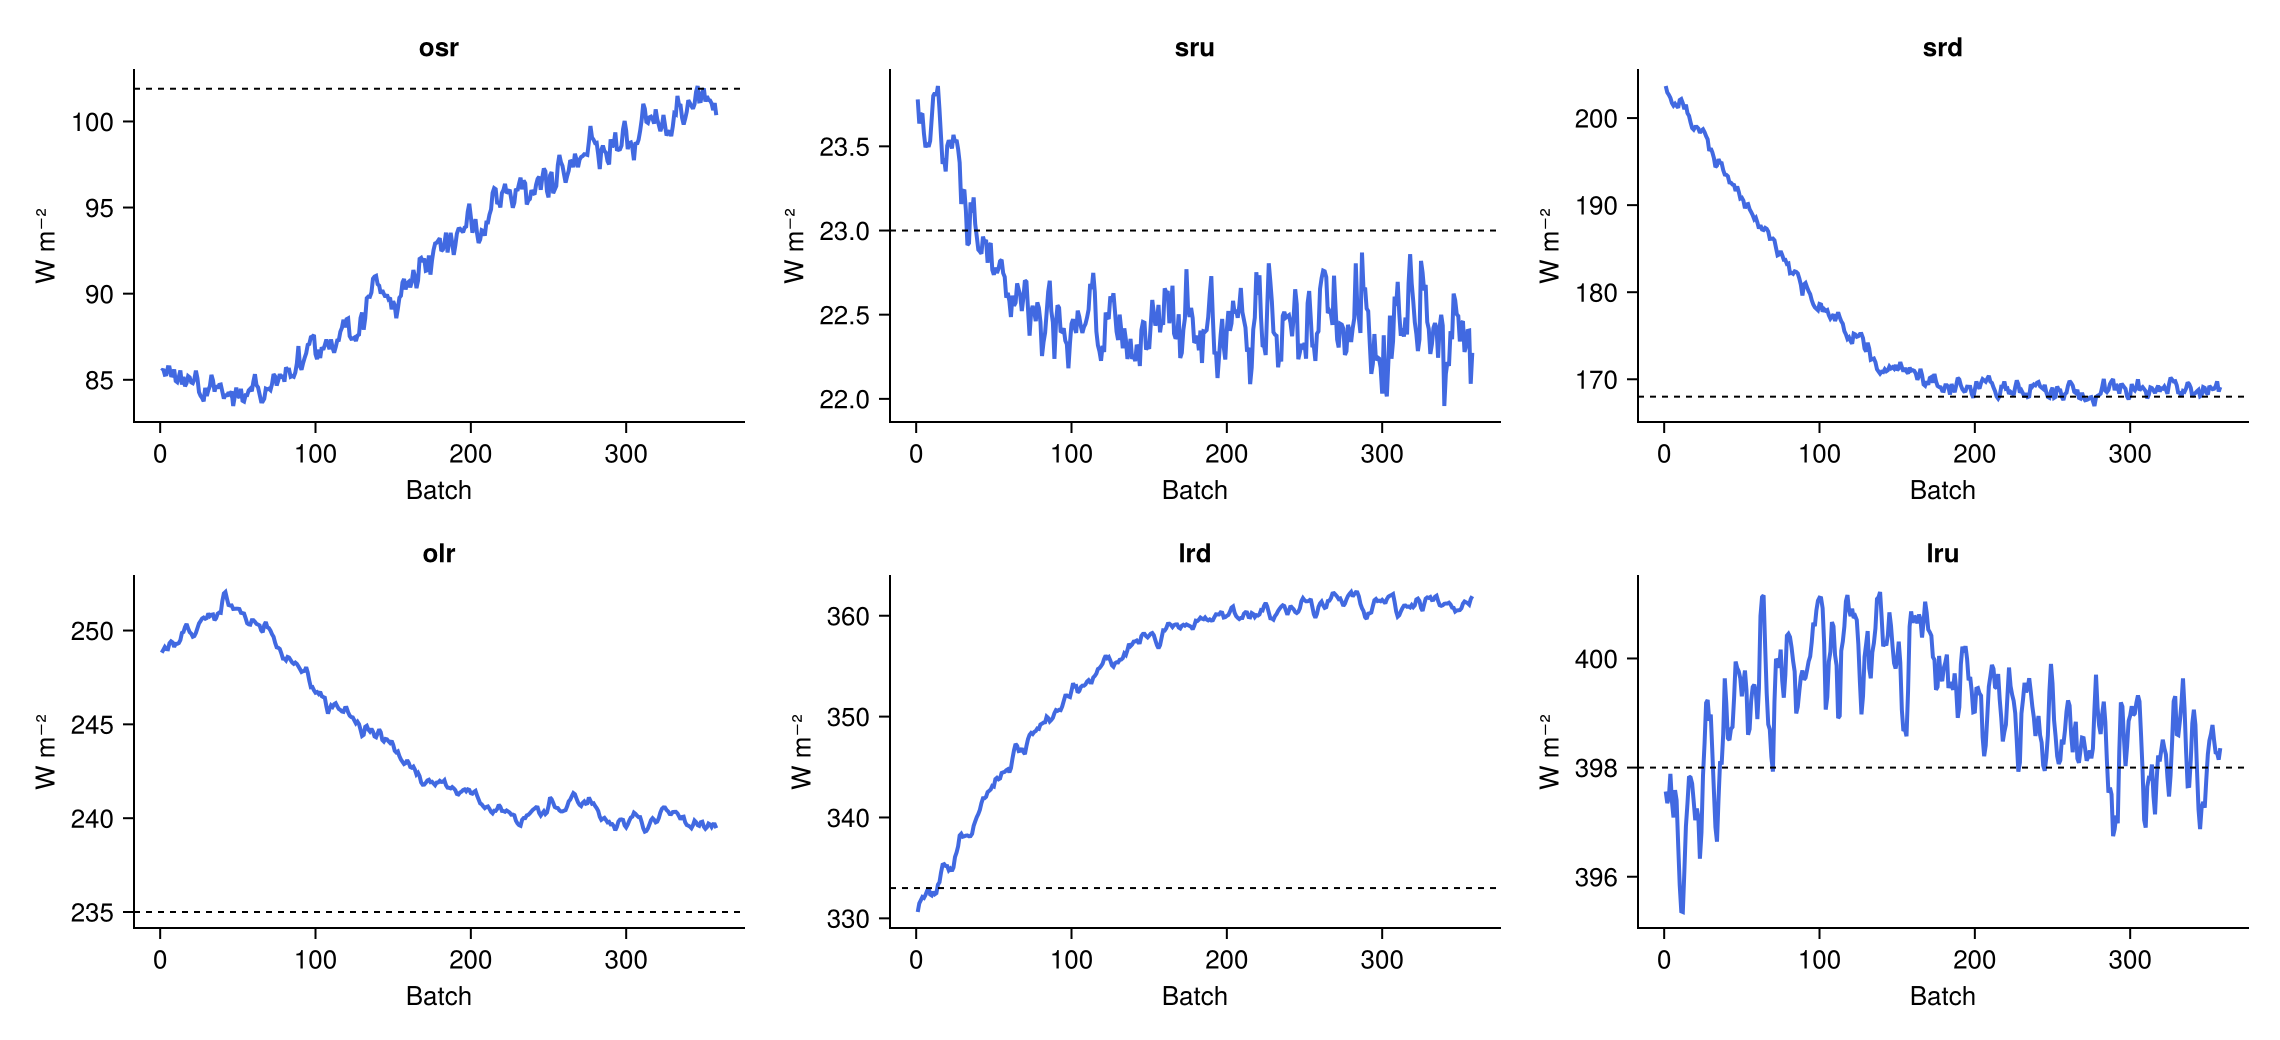

In [11]:
figs.fig_flux

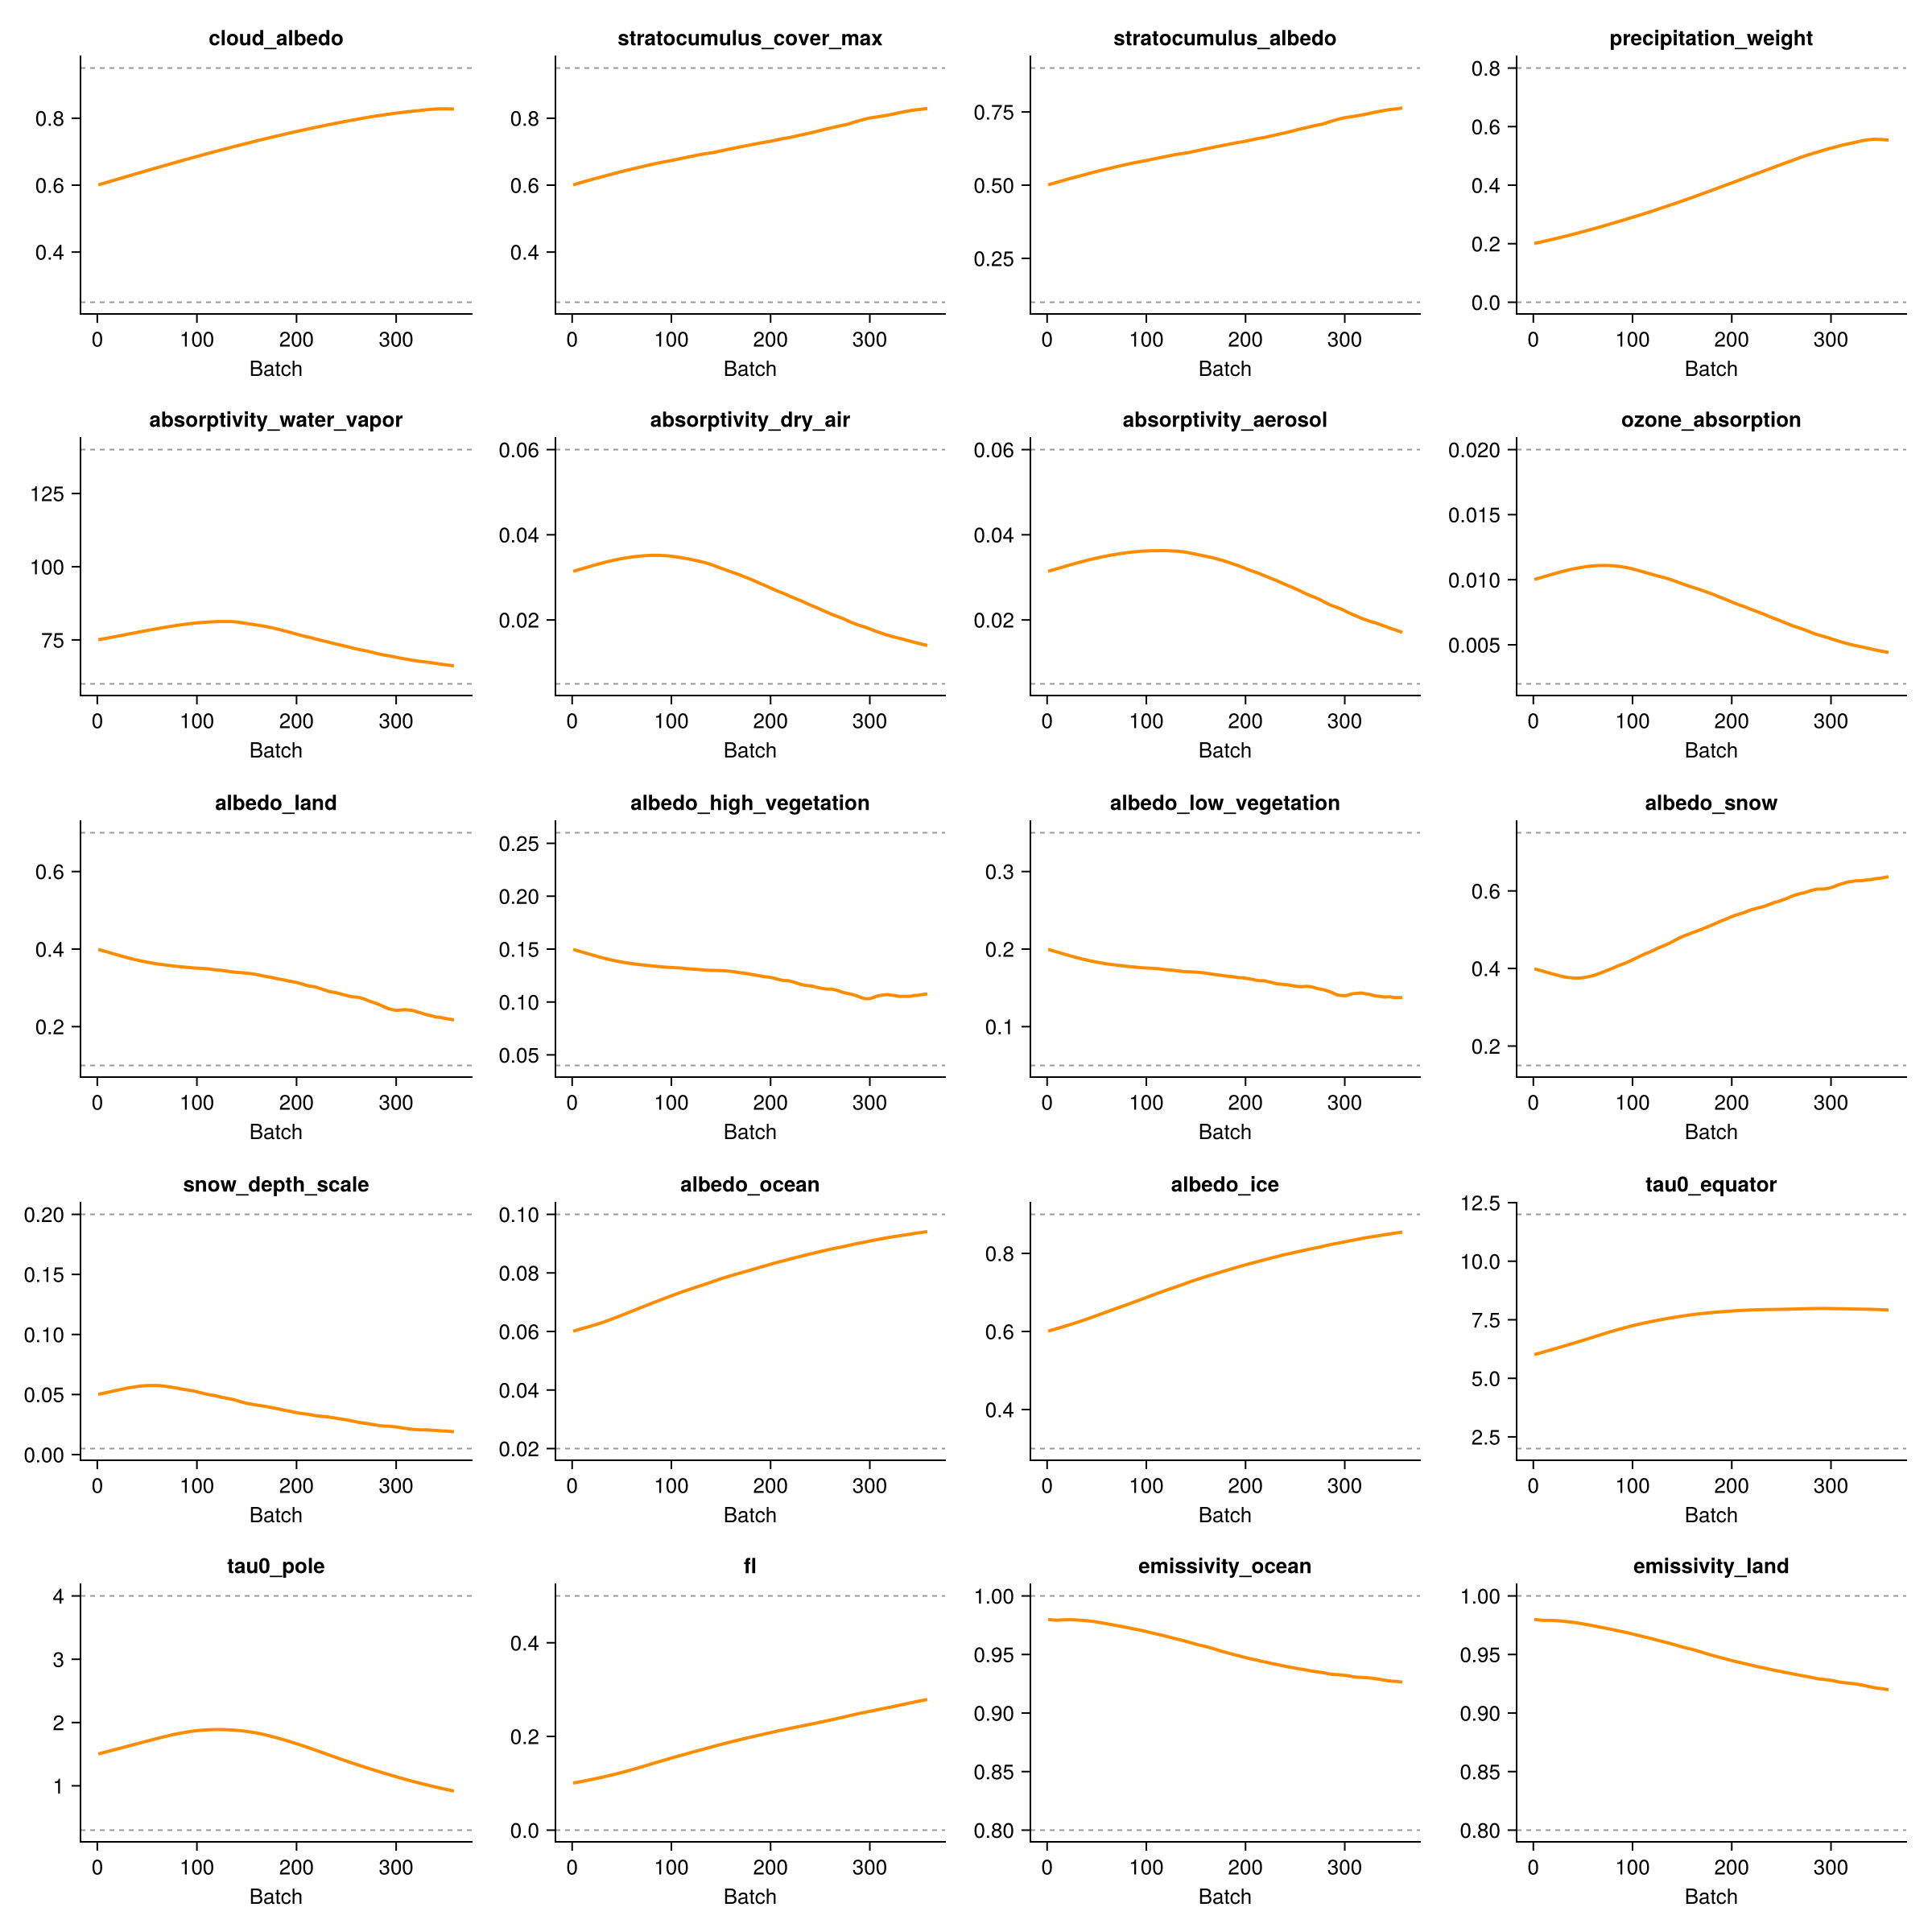

In [12]:
figs.fig_params

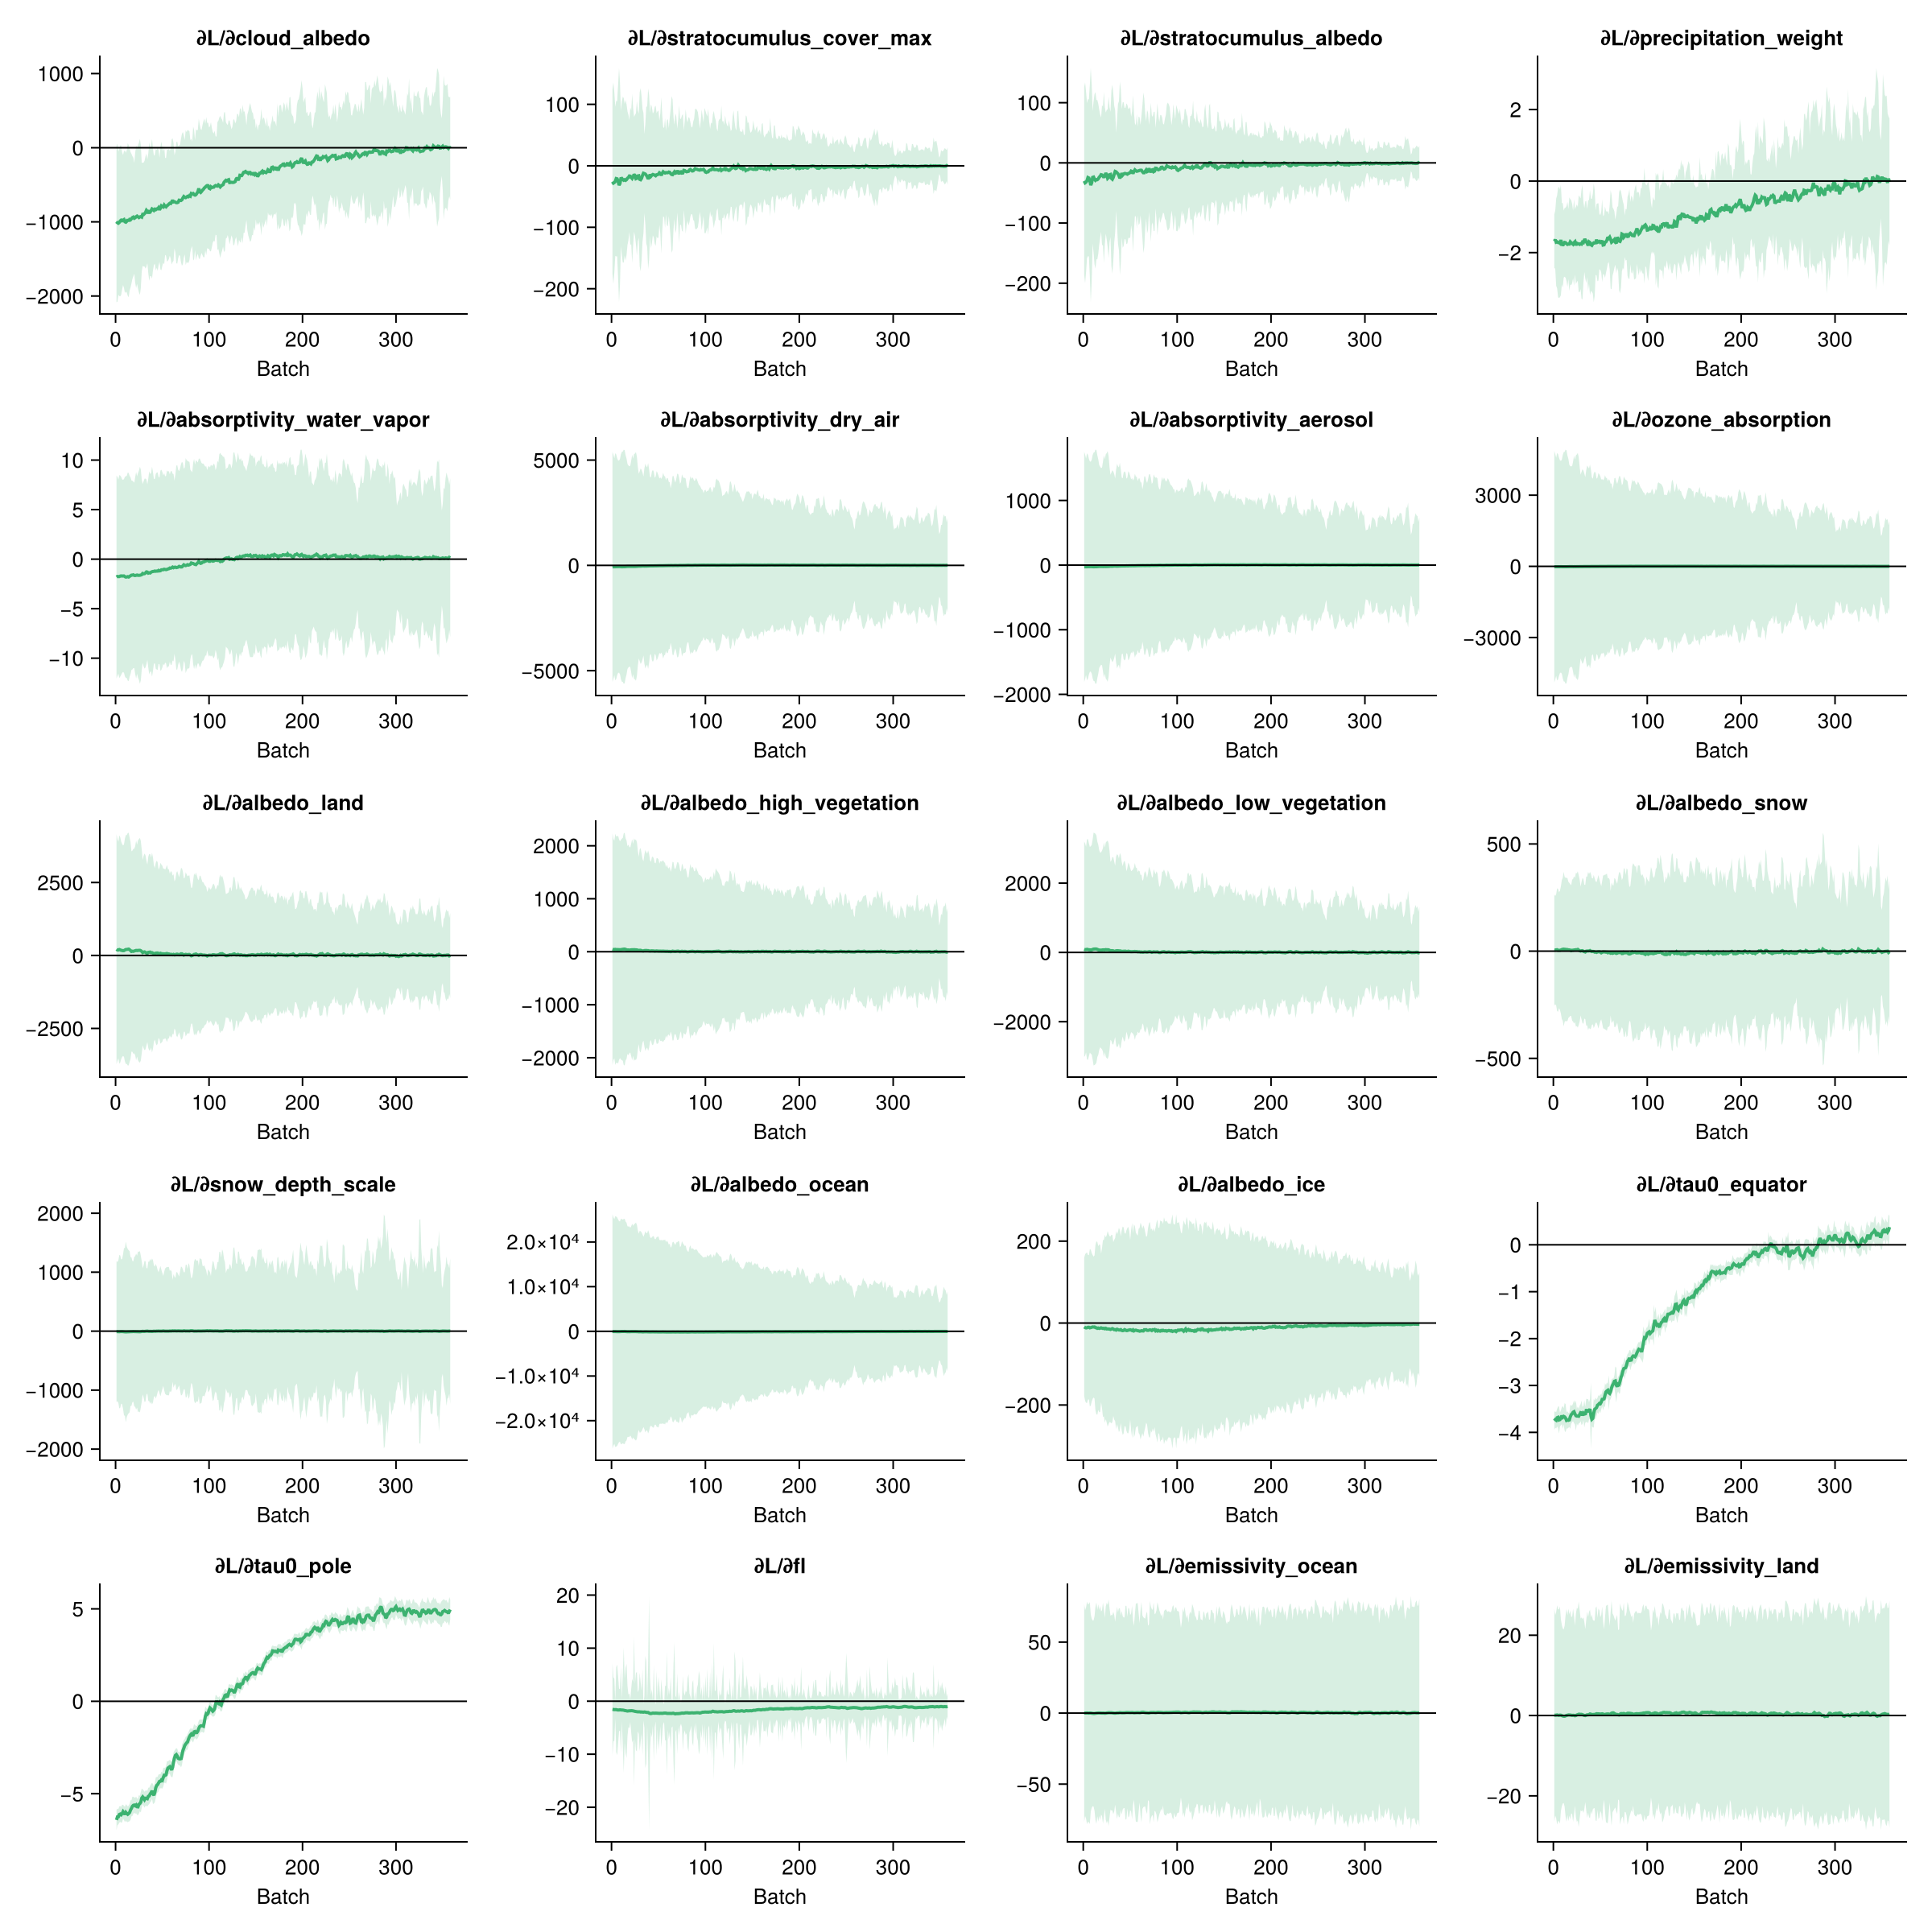

In [13]:
figs.fig_grads

## 8. Climate Validation

Compares default vs. trained equilibrium climatology across all 6 target fluxes + precipitation.

**⏱ Expected runtime: ~1–3 hours at T31.**

In [14]:
clm = run_climate_validation(result; n_years=7, stat_years=5, dt=Minute(20))

Climate run: default ...


 100% Time: 0:33:54 (2007-03-20, 297.32 years/day,  99 m/s, [-102,   44] ˚C)


Climate run: trained ...


 100% Time: 0:55:30 (2007-03-20, 181.58 years/day, 106 m/s, [-107,   37] ˚C)


(default = (osr = 72.846504f0, olr = 272.45572f0, srd = 177.56392f0, sru = 17.853838f0, lrd = 341.8073f0, lru = 399.00992f0, precip_total = 3.2176092f0, temp_profile = Float32[254.33943, 245.0881, 246.5963, 250.99757, 259.19992, 266.8099, 273.2447, 279.63647]), trained = (osr = 98.67651f0, olr = 246.91751f0, srd = 160.944f0, sru = 18.98804f0, lrd = 368.5635f0, lru = 400.7977f0, precip_total = 3.3898036f0, temp_profile = Float32[225.30688, 235.62195, 248.22847, 258.3559, 267.0657, 274.04355, 279.6999, 284.77756]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lrd, lru, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int6

In [15]:
targets = result.loss_config.targets

@printf("%-6s  %8s  %9s  %9s  %9s  %9s\n",
        "flux", "target", "def val", "def bias", "trn val", "trn bias")
println("-" ^ 60)
for k in result.loss_config.flux_keys
    tgt    = targets[k]
    d_val  = getproperty(clm.default, k)
    t_val  = getproperty(clm.trained, k)
    @printf("%-6s  %8.2f  %9.2f  %+9.2f  %9.2f  %+9.2f\n",
            k, tgt, d_val, d_val-tgt, t_val, t_val-tgt)
end
println()
println("Held-out diagnostics (not in loss):")
@printf("  Precipitation:  default = %.2f mm/day  trained = %.2f mm/day  (ERA5 ≈ 2.74)\n",
        clm.default.precip_total, clm.trained.precip_total)

flux      target    def val   def bias    trn val   trn bias
------------------------------------------------------------
osr       101.90      72.85     -29.05      98.68      -3.22
sru        23.00      17.85      -5.15      18.99      -4.01
srd       168.00     177.56      +9.56     160.94      -7.06
olr       235.00     272.46     +37.46     246.92     +11.92
lrd       333.00     341.81      +8.81     368.56     +35.56
lru       398.00     399.01      +1.01     400.80      +2.80

Held-out diagnostics (not in loss):
  Precipitation:  default = 3.22 mm/day  trained = 3.39 mm/day  (ERA5 ≈ 2.74)


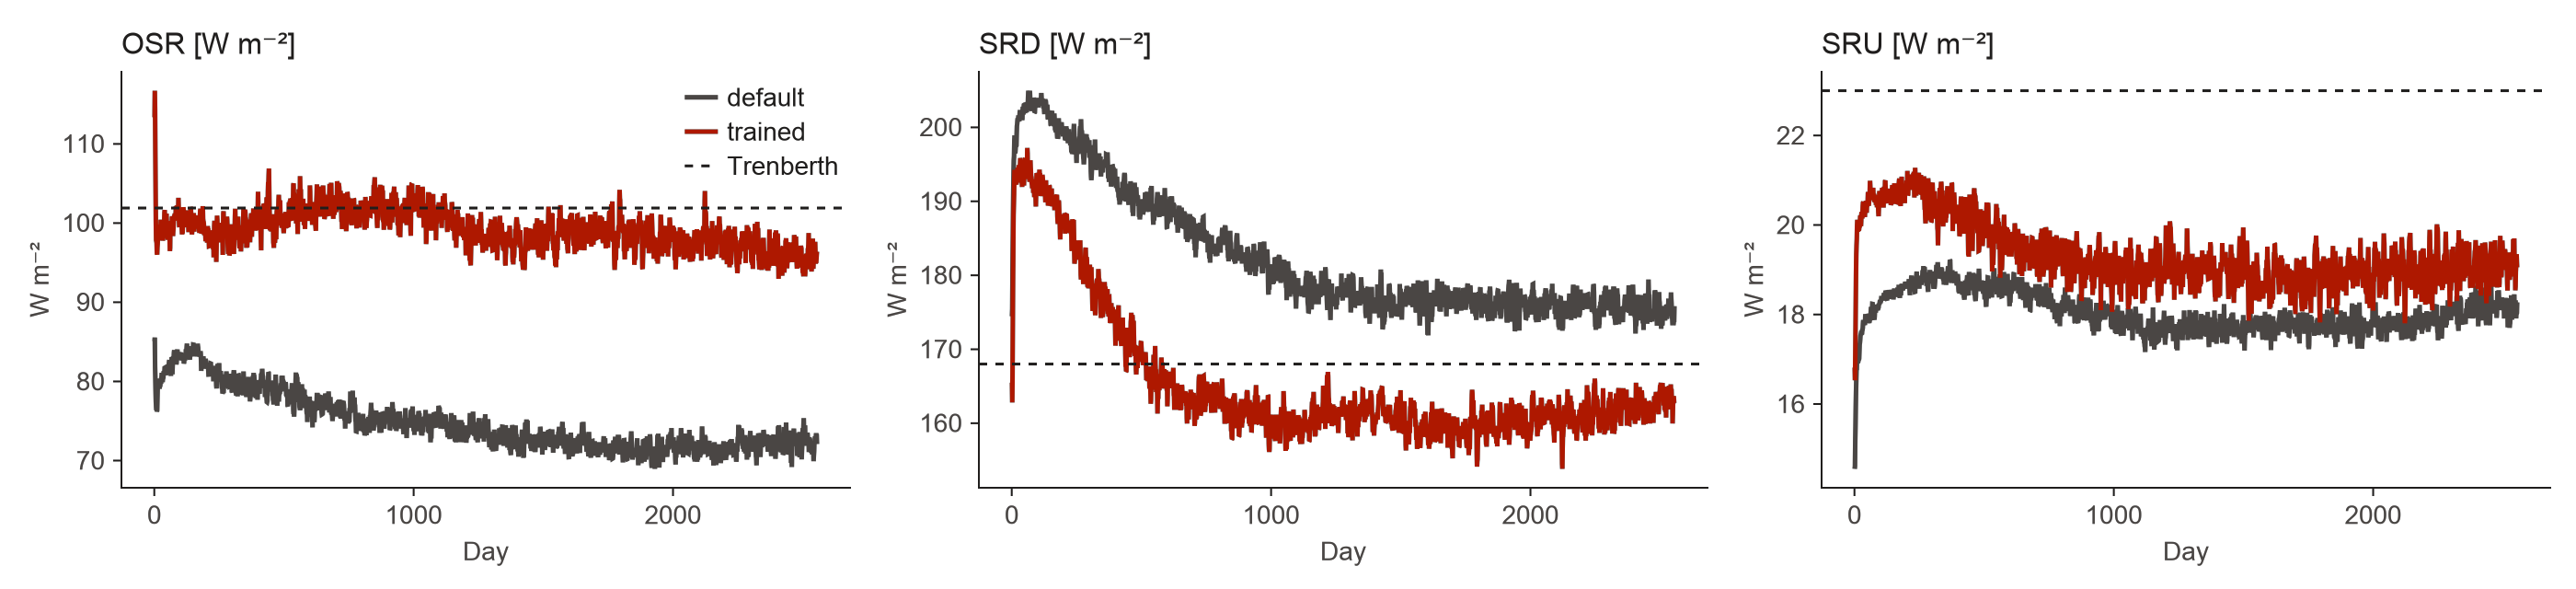

In [16]:
cfigs = plot_climate(clm;
    save_dir    = joinpath(@__DIR__, "output", "trenberth_perblock_clip"),
    loss_config = result.loss_config,
)
cfigs.fig_rad

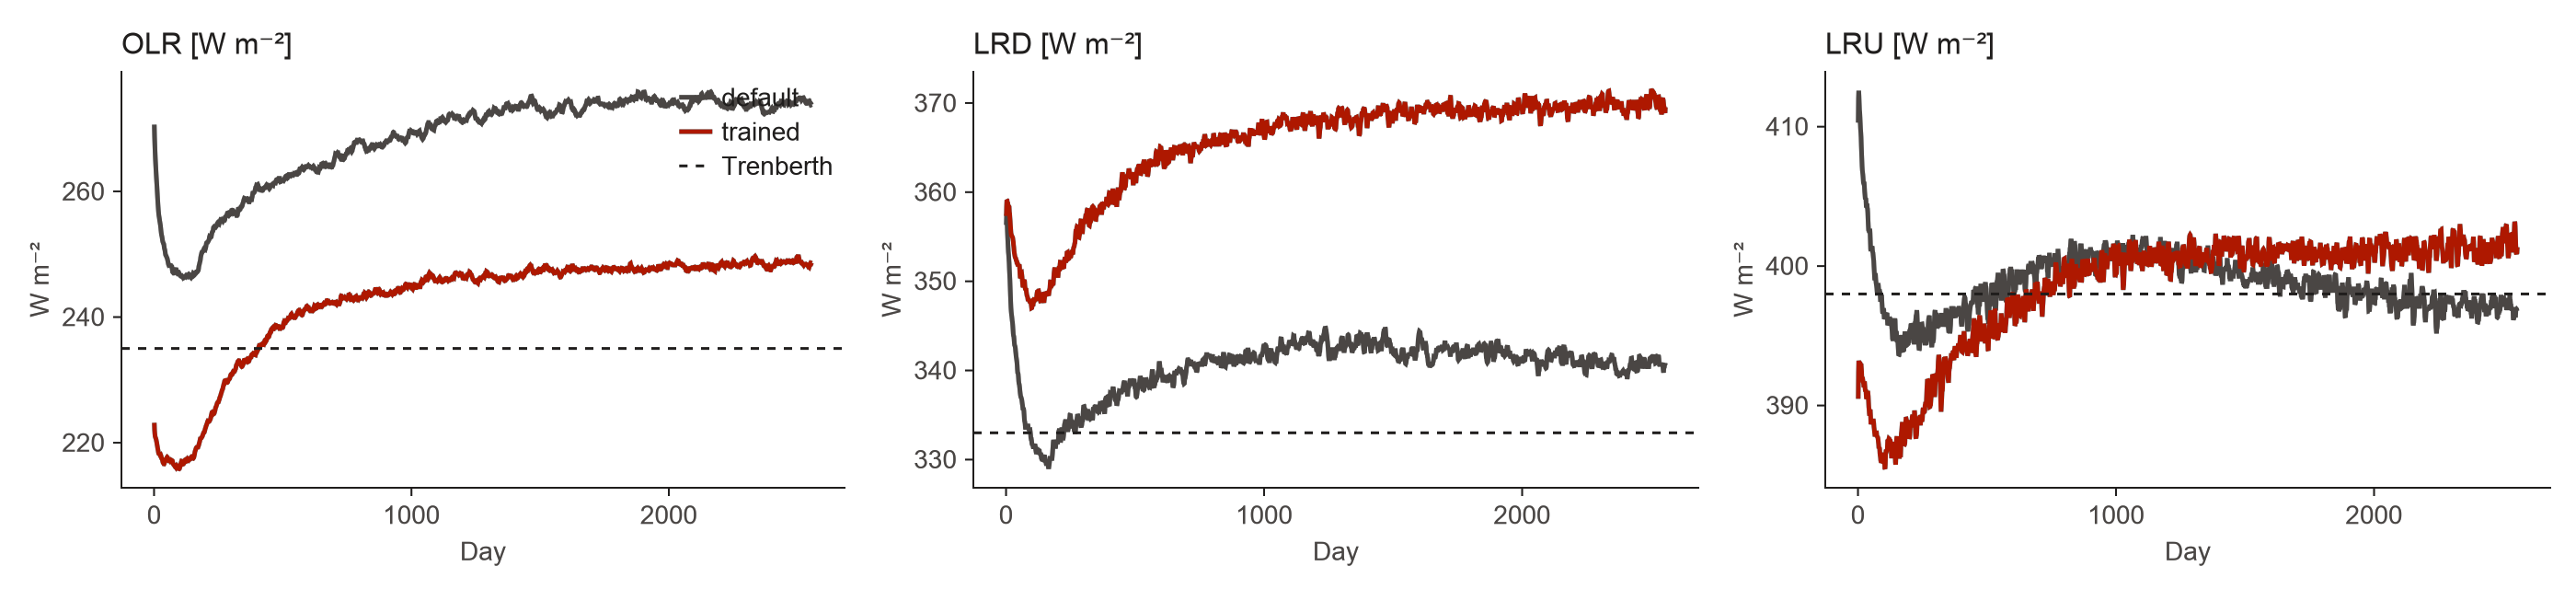

In [17]:
cfigs.fig_lw

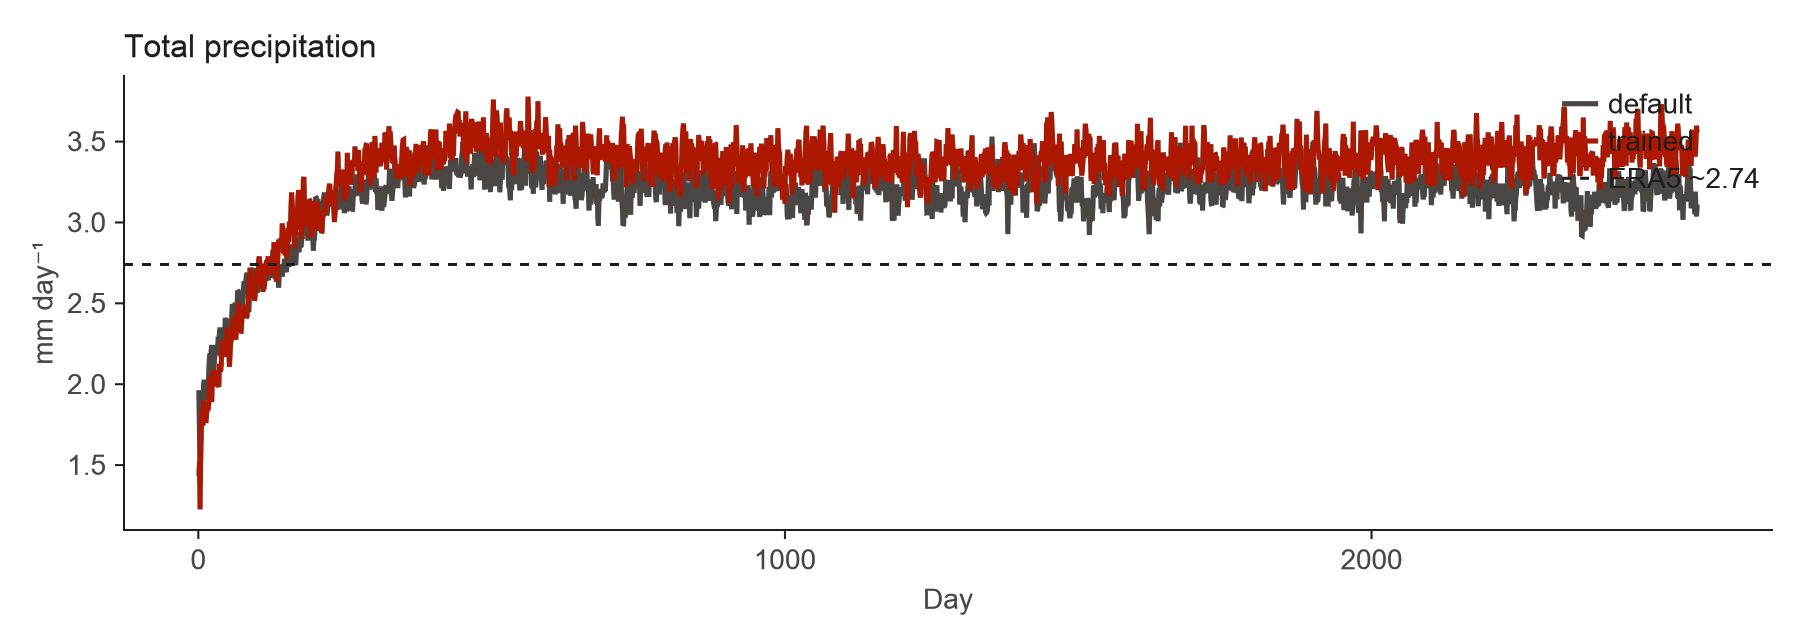

In [18]:
cfigs.fig_precip

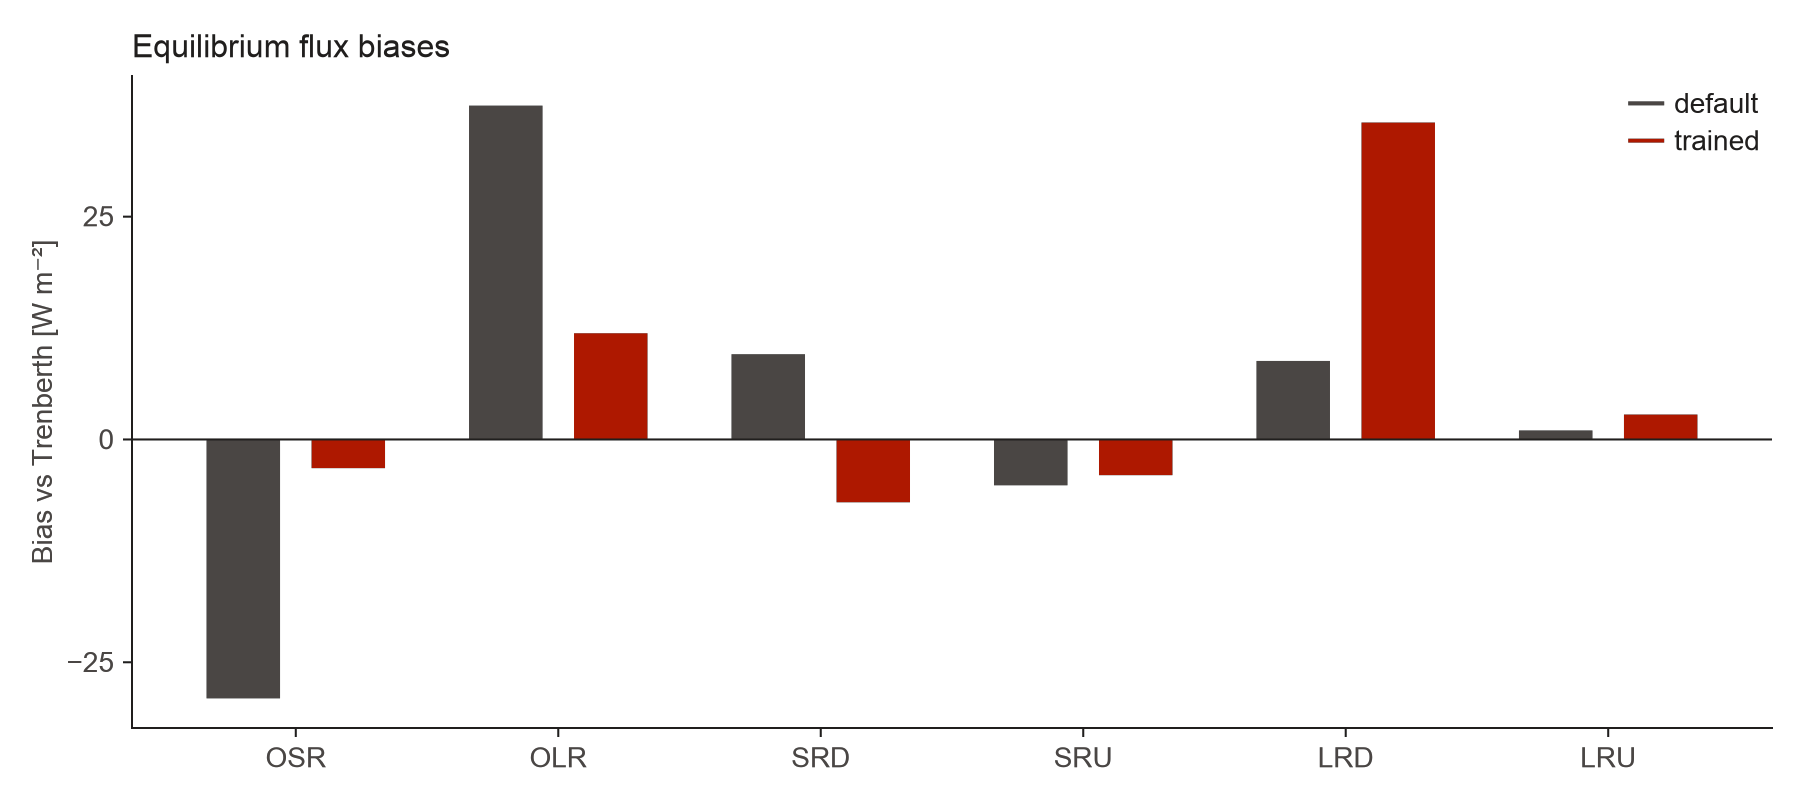

In [19]:
cfigs.fig_summary

## 9. Interpretation

**What to check against the `trenberth_full.ipynb` production baseline** (`osr` +1.58, `sru` -3.61,
`srd` -12.37, `olr` +12.67, `lrd` +28.50, `lru` +0.89 vs. default `osr` -29.05, `sru` -5.15,
`srd` +9.56, `olr` +37.46, `lrd` +8.81, `lru` +1.01):

- Does `history[:grad_norm]`/`clipped` (Section 5's diagnostics) show a *different* per-block
  clipping pattern than the global-norm baseline — i.e. did splitting the budget actually change
  which parameters get to move on a given batch?
- Does `srd`/`lrd` end up less bad than the production baseline at true equilibrium (Section 8),
  or does the SW block just converge faster while `srd`/`lrd` still drift the same way? If the
  latter, the shared-clip-budget wasn't the actual bottleneck — the SW↔LW physical coupling
  (shared transmissivity field, see memory) is, and this experiment cleanly rules that out
  without needing to touch AD machinery.